# Working with time in Pandas

Dataset Source: Yahoo finance, seaborn in python and Kaggle.com


KATE expects your code to define variables with specific names that correspond to certain things we are interested in.

KATE will run your notebook from top to bottom and check the latest value of those variables, so make sure you don't overwrite them.

* Remember to uncomment the line assigning the variable to your answer and don't change the variable or function names.
* Use copies of the original or previous DataFrames to make sure you do not overwrite them by mistake.

You will find instructions below about how to define each variable.

Once you're happy with your code, upload your notebook to KATE to check your feedback.

KATE expects your code to define variables with specific names that correspond to certain things we are interested in.

KATE will run your notebook from top to bottom and check the latest value of those variables, so make sure you don't overwrite them.

* Remember to uncomment the line assigning the variable to your answer and don't change the variable or function names.
* Use copies of the original or previous DataFrames to make sure you do not overwrite them by mistake.

You will find instructions below about how to define each variable.

Once you're happy with your code, upload your notebook to KATE to check your feedback.

## About the data

<br>

You are provided with three data sets. The first is a time series from Carnival Corp containing their stock prices from the London Stock Exchange (LSE). On the LSE the name of the ticker is `CLL` . This data was taken from Yahoo finance. This dataset was already pre-processed to exclude missing values and is provided in the form of a CSV file. The table below shows the columns in the given file.


| CLL_price |  Europe/London            |
| ---------:| -------------------------:|
| 10.8474   | 2012-03-09 01:00:00+00:00 |
| ...       | ...                       |

The second data set contains information about 300 diamonds. This data set was obtained from the package `seaborn` in Python. The data contains the price and carat of each diamond. The columns: source date, transfer date and the date each diamond was sold are also included. There is also a time zone column that contains the time zone data for each transfer date specifically. 

| carat | price | source_date | transfer_date      | timezone  | sold_date                |
|:-----:|------:| -----------:| ------------------:| ---------:| ------------------------:| 
| 0.74  | 2797  | 2010-03-24  | 2010-09-03 05:23:41| Etc/GMT-1 |2011-11-17 01:51:38 000000|
| ...   | ...   | ...         | ...                | ...       | ...                      |


The last data set contains information about different stocks traded on Indian markets. The data contains nanoseconds from `2017-06-19 03:30:01.338579` to `2017-06-19 04:29:00.543904` with 55597 rows of data. We will only focus on two stocks from ACC Cement. The instrument token for each stock is contained in the data together with the price for each stock. This data set was obtained from Kaggle.com. 

| timestamp                  | instrument_token| last_price  |
|:--------------------------:| ---------------:| -----------:|
| 2017-06-19 03:30:01.338579 | 5215745 	       | 256.25      |
| ...                        | ...             | ...         |                       


<br>

## About the assignment

<br>

The Pandas library has a rich portfolio of classes and functions for handling dates and times. Using `Timestamp()` and other classes, we can elegantly handle datetime objects within tabular data and dataframes. This assignment takes you through some of the key functions and patterns for using datetimes in Pandas in the financial industry.

The official user guide is available [here](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html) and `Timestamp` documentation can be found [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Timestamp.html).


## Setup

<br>

To complete this assignment, we will import numpy and pandas for data manipulation and later on in the notebook we will import matplotlib together with pylab for data visualisation.

In [1]:
# Import libraries
import numpy as np
import pandas as pd

## Convert a datetime associated with a stock price to a different timezone

<br>

The dataset for this section of the assignment contains stocks for Carnival Corporation; Carnival is an internationally traded organisation whose stock prices need to be interpretted by investors in many different timezones. It is dual listed on London Stock Exchange(LSE) and New York Stock Exchange(NYSE), though for our purpose we will use the data from LSE. 

In the dataset there are two columns:  `CLL_price` is the stock price (CLL is the ticker name on LSE, ie a unique identifier for trading purposes) and `Europe/London` contains the associated datetime information, including timezone offset. With the help of Pandas you can convert these timezones to many other timezones for additional analysis.

Let's load the dataset from `data/time_zones.csv` into a `pandas` data frame.

We can also inspect the loaded dataset with `.head()`, `.tail()` and other methods of choice.

In [2]:
tz = pd.read_csv('data/time_zones.csv')

tz.head()
tz.tail()

,CLL_price,Europe/London
73,10.8474,2012-03-09 01:00:00+00:00
74,10.9450,2012-03-09 02:00:00+00:00
75,11.0208,2012-03-09 03:00:00+00:00
76,11.0750,2012-03-09 04:00:00+00:00
77,11.0800,2012-03-09 05:00:00+00:00


You can easily convert a date and time related column into a Timestamp object, and then convert that object's time zone infomation to a different time zone.

The tz package contains many different time zones to choose from: [Link](https://en.wikipedia.org/wiki/List_of_tz_database_time_zones)

**Q1. Convert the column`'Europe/London'`to a Timestamp with the `pd.to_datetime()` function and assign this to  `tz['Europe/London']`.**

**Create a column `Australia/Broken_Hill` in data frame `tz` containing the time zone data for Broken Hill in Australia and assign this to `tz['Australia/Broken_Hill']`. Use the `dt` package function `dt.tz_convert()` to convert the time zone data from `tz['Europe/London']` to `Australia/Broken_Hill`.**


**Lastly, create a variable called `str_aus_time_zone` that contains the first timestamp at index 0 of `tz['Australia/Broken_Hill']` as a string. You can use the `str()` function to do this.**


<br>

In [3]:
# Your code here
# tz['Europe/London'] =
# tz['Australia/Broken_Hill'] = 
# str_aus_time_zone =


# print(str_aus_time_zone)

# Your code here
tz['Europe/London'] = pd.to_datetime(tz['Europe/London'])

# Create column Australia/Broken_Hill containing the timezone data for Broken Hill in Australia
# Convert the timezone data from Europe/London to Australia/Broken_Hill
tz['Australia/Broken_Hill'] = tz['Europe/London'].dt.tz_convert('Australia/Broken_Hill')

# Create a variable that contains the first timestamp as a string
str_aus_time_zone = str(tz['Australia/Broken_Hill'].iloc[0])

# Display the result to verify
print(str_aus_time_zone)

2012-03-06 10:30:00+10:30


## Examine bought and sold prices for diamonds

<br>

The data set for this section of the assignment contains information about diamonds. Column `carat` and `price` contain the carat and price for each diamond respectively. Column `source_date` and `sold_date` contain the sourced date of the diamond from the mine and the date the diamond was sold by the manufaturer respectively. Both of these columns are in Coordinated Universal Time(UTC). Column `transfer_date` contains the dates that each diamond was transfered from the mine to the manufacturer. Lastly, column `timezone` contains the different time zones associated with each of the transfer dates for the diamonds. There are two time zones: Etc/GMT-1 and Europe/Paris.

Let's load this from `data/diamonds.csv` into a `pandas` data frame.

We can also inspect the loaded dataset with `.head()`, `.tail()`,  `.shape`, and other methods of choice.

In [4]:
df = pd.read_csv('data/diamond_prices.csv')

df.tail()
df.head()

,carat,price,source_date,transfer_date,timezone,sold_date
0,0.23,326,2010-04-11,2010-10-10 09:08:02,Europe/Paris,2011-07-14 09:27:28 000000
1,0.21,326,2010-04-06,2010-11-02 14:05:22,Etc/GMT-1,2011-09-15 02:45:41 000000
2,0.23,327,2010-04-03,2010-09-07 16:51:13,Europe/Paris,2011-06-26 18:41:23 000000
3,0.29,334,2010-05-19,2010-08-17 21:05:39,Etc/GMT-1,2011-11-07 16:08:41 000000
4,0.31,335,2010-03-11,2010-12-23 11:44:36,Etc/GMT-1,2011-04-11 08:25:03 000000


In the code cell below, column `source_date` has been converted to a `Timestamp` in pandas with timezone UTC(+00:00). Notice the format code `'%Y-%m-%d'` was used because we only have the year, month and day for this column. The UNIX format codes for parsing and printing can be found here [here](https://strftime.org/). Below is a summary of the codes you will need for Question 2:

![](./img/q2_codes.png)


Column `sold_date` needs to be a `Timestamp` as well but here we have the year, month, day, hour, minute, second and even microsecond information.

**Q2. Parse column `sold_date` to a `Timestamp` with `pd.to_datetime()` using format codes to capture the full time information provided. Assign this column to `df['sold_date']`. Create another variable called `str_sold_datetime` that contains the third timestamp, ie at index 2, of the column `sold_date` as a string. You can use the `str()` function to do this.**

<br>

In [5]:
df['source_date'] = pd.to_datetime(df['source_date'],  
                                      format='%Y-%m-%d', utc=True)
# Your code here
# df['sold_date'] =
# str_sold_datetime =

# print(str_sold_datetime)

df['sold_date'] = pd.to_datetime(df['sold_date'], format='%Y-%m-%d %H:%M:%S %f', utc=True)
str_sold_datetime = str(df['sold_date'].iloc[2])

print(str_sold_datetime)


2011-06-26 18:41:23+00:00


Now, both columns `source_date` and `sold_date` are `Timestamps` with timezone UTC.

Notice that the time zones in column `timezone` and column `transfer_date` are not in UTC. 
The `transfer_date` column needs to be in the same format as columns `source_date` and `sold_date`. To do this the `transfer_date` column has been converted to a `datetime` object in the code cell below. The format code `'%Y-%m-%d %H:%M:%S'` was used as we have the year, month, day, hour, miute and second information for this column.

We want `source_date`, `transfer_date` and `sold_date` to have the same timezone information in UTC.
Here you will find a useful article that will help you with Question 3:
[Link](https://medium.com/@billydoyle/python-pandas-datetimes-and-timezones-1b4565ee0d34)


**Q3. Create a column `df['transfer_date_UTC']` that contains the transfer date `timestamps` with the timezone in UTC.**

**Hint: We recommend creating a function `convert_tz_to_UTC(row)`, which takes a row from the DataFrame. The function will 1) "loads" the timezone using  `dt.tz_localize()` with `transfer_date` and `timezone` and 2) convert the result back to UTC using `tz_convert('UTC')`. You can then use `apply` to apply your function on each row of the Dataframe one by one, to do so make sure to pass the parameters `axis=1` to `apply` -- this will allow you to create the new `transfer_date_UTC` column.**

**Finally, create a variable called `str_transfer_datetime` that contains the first timestamp at index 0 of the `transfer_date_UTC` column you created as a string.**

<br>

In [6]:
df['transfer_date'] = pd.to_datetime(df['transfer_date'], 
                              format='%Y-%m-%d %H:%M:%S')
# Your code here
# group_by_timezone =
# transfer_date_sorted = 
# df['transfer_date_UTC'] = 
# str_transfer_datetime = 


# print(str_transfer_datetime)

group_by_timezone = df.groupby('timezone')


transfer_date_sorted = df.sort_values(by='transfer_date')


def convert_tz_to_UTC(row):
    localized = row['transfer_date'].tz_localize(row['timezone'])
    return localized.tz_convert('UTC')


df['transfer_date_UTC'] = df.apply(convert_tz_to_UTC, axis=1)


str_transfer_datetime = str(df['transfer_date_UTC'].iloc[0])


print(str_transfer_datetime)

2010-10-10 07:08:02+00:00


Notice that columns `source_date`, `transfer_date_UTC` and `sold_date` have the same UTC format.

Note that the columns `transfer_date` and `timezone` are now redundant. 

**Q4. Create a new data frame `df_utc` where you drop the `transfer_date` and `timezone` columns. You can use the method `drop` for that. Make sure that `df_utc` does not contain NaN with the `dropna()` method. Then create a column `diff_trans_bought` in data frame `df_utc` as `df_utc['diff_trans_bought']`. This column should indicate the difference between column `sold_date` and `transfer_date_UTC` for each observation in number of days, hours, minutes and seconds. Create a variable called `str_difference` that contains the fourth timestamp, ie at index 3, of the `diff_trans_bought` column you created as a string.**

<br>

In [7]:
# Your code here
# df_utc['diff_trans_bought'] = 
# str_difference = 


# print(str_difference)

# Your code here

# Step 1: Drop redundant columns 'transfer_date' and 'timezone'
df_utc = df.drop(['transfer_date', 'timezone'], axis=1)

# Step 2: Drop any rows with NaN values
df_utc = df_utc.dropna()

# Step 3: Calculate the difference between sold_date and transfer_date_UTC
df_utc['diff_trans_bought'] = df_utc['sold_date'] - df_utc['transfer_date_UTC']

# Step 4: Get the difference at index 3 as a string (if it exists)
str_difference = str(df_utc['diff_trans_bought'].iloc[3]) if len(df_utc) > 3 else "Index 3 does not exist"

# Print the result
print(str_difference)


446 days 20:03:02


Printing allows you to transform a `timestamp` to a string. Printing formatting codes are the same as for the Python library `time.strftime()` which can be found [here](https://strftime.org/).

**Q5. Create a variable `str_sold` that outputs the string: 'The diamond was sold on 09:27 on 14 Jul in 2011' for the first diamond at index 0 in the data set `df_utc`. You can use the `.strftime()` function to do this.**

<br>

In [8]:
# Your code here
# str_sold = 


# print(str_sold)


# Format the sold_date timestamp at index 0 into the required string format
str_sold = "The diamond was sold on " + df_utc['sold_date'].iloc[0].strftime('%H:%M on %d %b in %Y')

# Print the result
print(str_sold)


The diamond was sold on 09:27 on 14 Jul in 2011


## Indian Stock Data: seeking arbitrage possibilities

<br>

The data set `tick_data` for this section of the assignment contains different stocks from indian markets in UTC. There is a 5 hour and 30 minute difference between India Standard Time (IST) and UTC. 

The column `timestamp` contains the stock trading times up to the nanosecond over 2 hours from `2017-06-19 03:30:01.338579` to `2017-06-19 04:29:00.543904`. Column `instrument_token` contains the codes that identify each stock. The column `last_price` contains the close price for each stock at the time specified in the `timestamp` column.

Let's load the stocks_india dataset from `data/stocks_india.csv` into a `pandas` data frame.

We can also inspect the loaded dataset with `.head()`, `.tail()`,  `.shape`, and other methods of choice.

In [9]:
tick_data = pd.read_csv('data/stocks_india.csv')

tick_data.tail()
tick_data.head()

,timestamp,instrument_token,last_price
0,2017-06-19 03:30:01.338579,1510401,509.15
1,2017-06-19 03:30:01.338657,340481,1635.20
2,2017-06-19 03:30:01.338689,7458561,375.00
3,2017-06-19 03:30:01.338715,315393,1117.70
4,2017-06-19 03:30:01.338739,60417,1143.00


In the cell below, column `timestamp` in data frame `tick_data` is converted to a `datetime` object. Notice that `unit='ns'`  was used to account for nanosecods in the data.

The market opens at 03:45:00.000 UTC and we want to remove pre-market data for our purposes. This has been done in the cell below. 

In [10]:
tick_data['timestamp'] = pd.to_datetime(tick_data["timestamp"], unit='ns')

tick_data = tick_data.loc[tick_data['timestamp'] > '2017-06-19 03:45:00.000']
tick_data

,timestamp,instrument_token,last_price
6787,2017-06-19 03:45:01.419981,5215745,256.25
6788,2017-06-19 03:45:01.420056,70401,656.00
6789,2017-06-19 03:45:01.420120,177665,537.10
6790,2017-06-19 03:45:02.344845,345089,3793.80
6791,2017-06-19 03:45:02.344916,232961,28846.80
...,...,...,...
55592,2017-06-19 04:29:00.543773,128178180,1096.00
55593,2017-06-19 04:29:00.543823,128076804,1117.80
55594,2017-06-19 04:29:00.543852,348929,196.25
55595,2017-06-19 04:29:00.543878,128209924,1144.20


Notice that the first timestamp is not `2017-06-19 03:30:01.338579` but `2017-06-19 03:45:01.419981` because of filtering out the pre-market data.	

The ACC Cement company has dual listed stocks which could present an arbitrage opportunity. ACC Cement is listed on the NSE(National Stock Exchange of India Limited) with code 5633 in the `instrument_token` column. Similarly, ACC Cement is listed on the BSE(Bombay Stock Exchange) with code 128104964 in the `instrument_token` column.

Two data sets are created: `acc_nse` and `acc_bse` for each of the dual listed stocks. 

In [11]:
acc_nse = tick_data[tick_data.instrument_token == 5633]
acc_bse = tick_data[tick_data.instrument_token == 128104964]

The timestamp column for each data frame is converted to an index column to allow for easy plotting.

In [12]:
acc_bse = acc_bse.set_index(['timestamp'])
acc_nse = acc_nse.set_index(['timestamp'])

A graph is created with package `matplotlib.pyplot` in order to visualise the all the opportunities for arbitrage between these two stocks over 2 hours.

/tmp/ipykernel_31/4210444807.py:5: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(acc_bse.index, acc_bse.last_price,'v-')
/tmp/ipykernel_31/4210444807.py:6: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(acc_nse.index, acc_nse.last_price, 'v-')


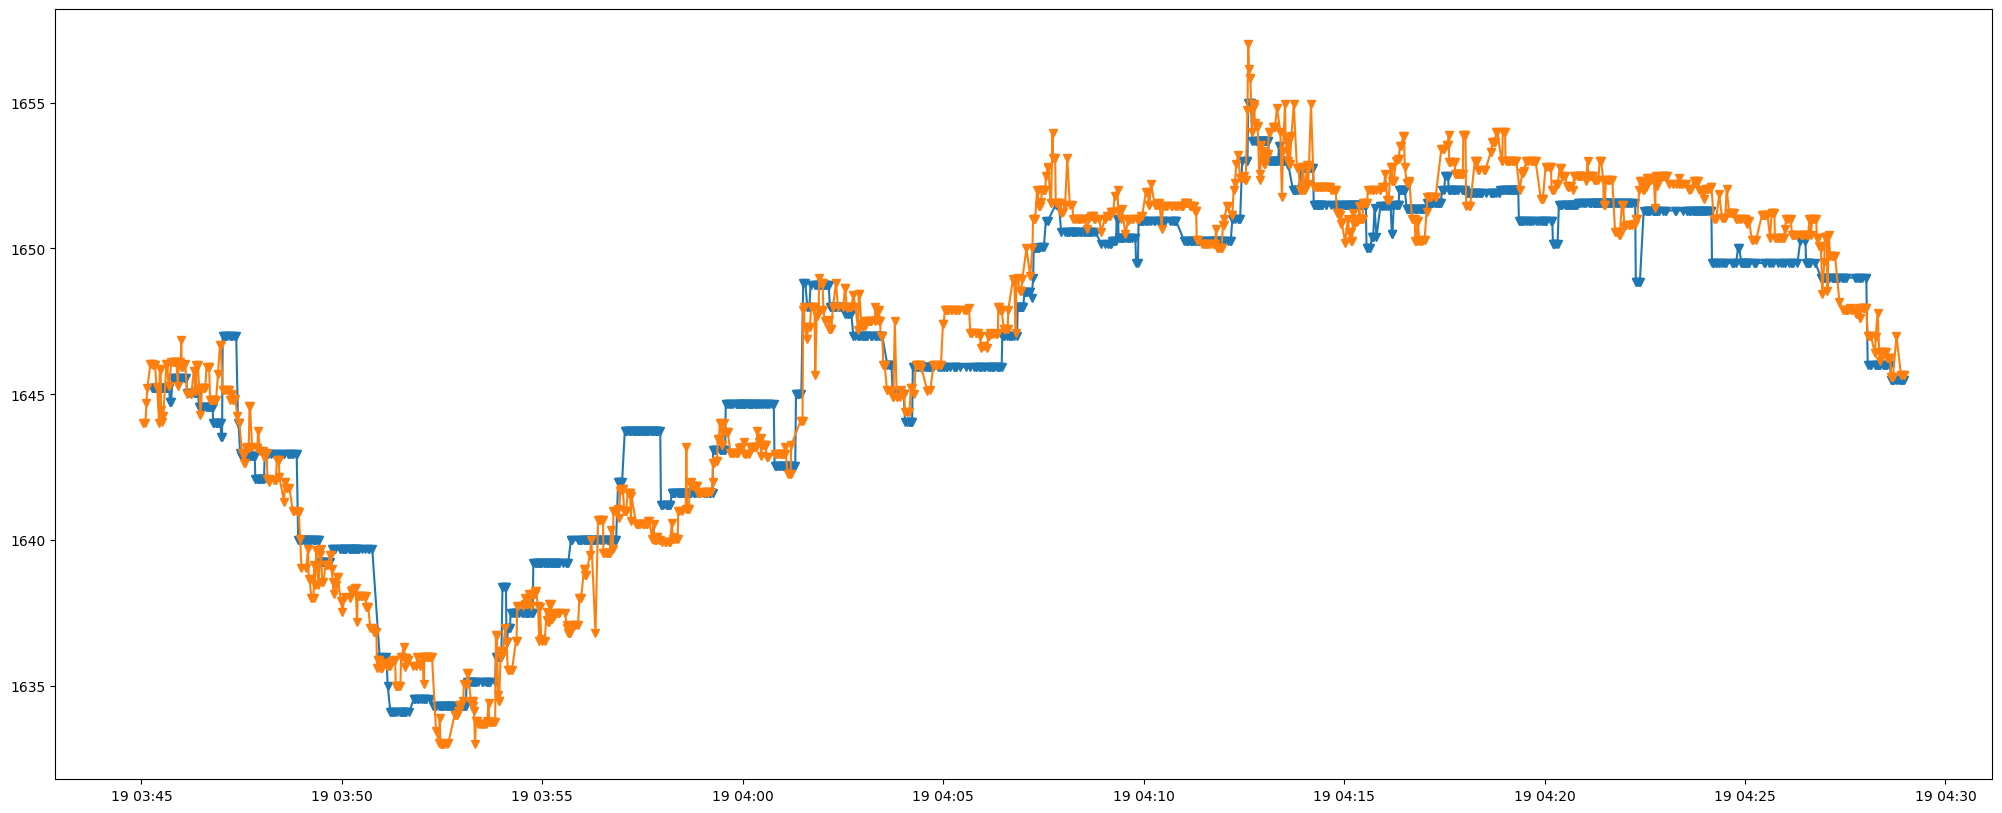

In [13]:
import matplotlib.pyplot as plt 
from pylab import rcParams
rcParams['figure.figsize'] = 25, 10
fig, ax = plt.subplots()
ax.plot_date(acc_bse.index, acc_bse.last_price,'v-')
ax.plot_date(acc_nse.index, acc_nse.last_price, 'v-')
plt.show()

Next, we'll examine the complete number of seconds that the price on the NSE was above a specific level, namely 1655. **Note**, we can see by eye that there is only one period when the stock price was above this level and this allows us to take a simplified approach to the calculation. The code would require further development if the price level had been set lower, thus encompassing multiple periods.

**Q6. Create a variable `number_seconds` indicating the whole number of seconds that the ACC Cement price on the NSE was above 1655. First, create a new dataframe, `above_df`, which contains entries where `last_price` is above 1655. Then find the difference between the maximum and minimum timestamps in `above_df` using `.index.max()` and `.index.min()` - this timedelta will contain nanosecond granularity. Finally, use .seconds to extract the complete number of seconds, assigning it to the variable `number_seconds`.**

<br>

In [14]:
# Your code here
# above_df = 
# number_seconds = 


# print(number_seconds)

# Your code here

# Filter the data to include only rows where the last price is above 1655
above_df = acc_nse[acc_nse['last_price'] > 1655]

# Calculate the time difference between the max and min timestamps of above_df
time_diff = above_df.index.max() - above_df.index.min()

# Extract the whole number of seconds from the time difference
number_seconds = time_diff.seconds

# Print the result
print(number_seconds)



3


**Q7. Create a variable `max_price_diff` containing the difference in price between the maximum price reached between 04:00 and 05:00 for ACC Cement on the NSE and the BSE. You can use `.index.hour == 4` to slice through each data frame and obtain only the data from 04:00 to 05:00 for each dataframe, calling these sliced dataframes `nse_hour_high` and `bse_hour_high` respectively. You can then use the .max() function on `last_price` column in each dataframe to find the maximum price over the hour.**

**Finally, take the difference between the two maximum prices, using abs() and int() to ensure the result is expressed as a positive integer and assigned to `max_price_diff`.**
<br>

In [15]:
# Your code here
# nse_hour_high = 
# bse_hour_high =
# max_price_diff = 


# print(max_price_diff)

# Your code here

# Slice data to get records from 04:00 to 05:00 on the NSE
nse_hour_high = acc_nse[acc_nse.index.hour == 4]

# Get the maximum price during this period on the NSE
nse_max_price = nse_hour_high['last_price'].max()

# Slice data to get records from 04:00 to 05:00 on the BSE
bse_hour_high = acc_bse[acc_bse.index.hour == 4]

# Get the maximum price during this period on the BSE
bse_max_price = bse_hour_high['last_price'].max()

# Calculate the absolute price difference and ensure it's an integer
max_price_diff = abs(int(nse_max_price - bse_max_price))

# Print the result
print(max_price_diff)


2
